# 📊 Laboratorio 2: Análisis Descriptivo y Transformación de Datos con Pandas

En el laboratorio anterior aprendimos a cargar datos, seleccionar columnas y manejar valores nulos. Hoy daremos el siguiente paso: **entender qué nos dicen los datos**.

Aprenderemos a calcular estadísticas, agrupar información para encontrar patrones, cruzar variables y crear nuevas columnas (Feature Engineering) para enriquecer nuestro análisis. También daremos nuestros primeros pasos creando gráficos directamente desde Pandas.

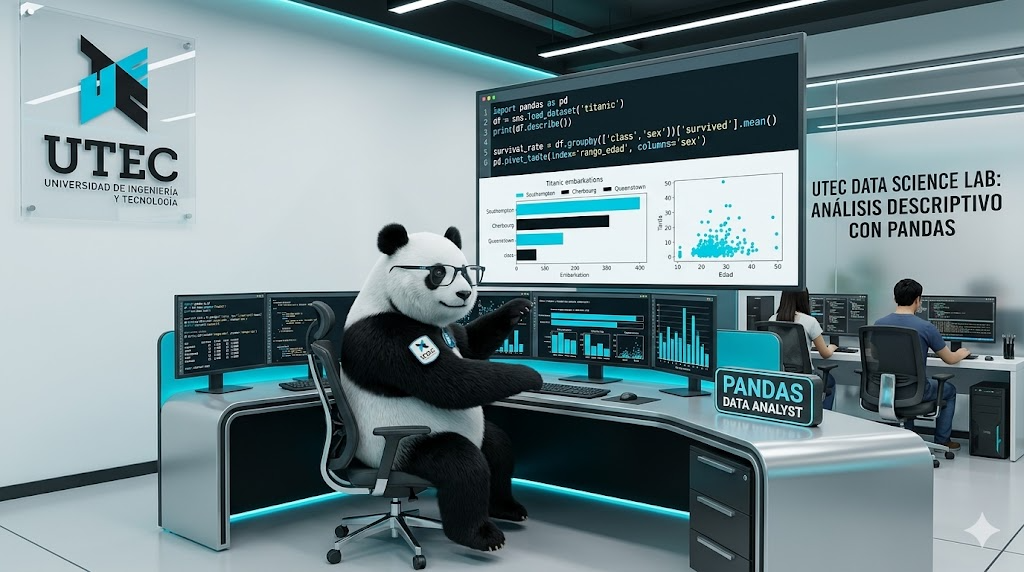

https://gemini.google.com/share/dcd1cb490090

### 1. Preparación del entorno y carga de datos
Iniciaremos importando las herramientas necesarias y cargando el dataset del Titanic.

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns

# Cargamos el dataset
df = sns.load_dataset('titanic')

# Revisamos la información general para recordar qué columnas tenemos
df.head(10)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
5,0,3,male,NaN,0,0,8.4583,Q,Third,man,True,NaN,Queenstown,no,True
6,0,1,male,54.0,0,0,51.8625,S,First,man,True,E,Southampton,no,True
7,0,3,male,2.0,3,1,21.0750,S,Third,child,False,NaN,Southampton,no,False
8,1,3,female,27.0,0,2,11.1333,S,Third,woman,False,NaN,Southampton,yes,False
9,1,2,female,14.0,1,0,30.0708,C,Second,child,False,NaN,Cherbourg,yes,False


**Ejercicio 0: Revision Preliminar**
- Qué variables contienen valores nulos?

In [2]:
df.dtypes

survived          int64
pclass            int64
sex              object
age             float64
sibsp             int64
parch             int64
fare            float64
embarked         object
class          category
who              object
adult_male         bool
deck           category
embark_town      object
alive            object
alone              bool
dtype: object

### 2. Estadística Descriptiva
Podemos analizar rápidamente la distribución de nuestras variables continuas y categóricas.

In [4]:
# Resumen de variables numéricas (promedio, desviación estándar, cuartiles)
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [3]:
# Resumen de variables categóricas o de texto
df.describe(include=['object', 'category'])

C:\Users\victor\AppData\Local\Temp\ipykernel_9804\1314900558.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include=['object', 'category'])


,sex,embarked,class,who,deck,embark_town,alive
count,891,889,891,891,203,889,891
unique,2,3,3,3,7,3,2
top,male,S,Third,man,C,Southampton,no
freq,577,644,491,537,59,644,549


In [5]:
# Frecuencias absolutas: ¿Cuántos pasajeros embarcaron en cada puerto?
print("Frecuencia Absoluta:")
print(df['embark_town'].value_counts())

print("\nFrecuencia Relativa (Porcentajes):")
# normalize=True nos da la proporción. Lo multiplicamos por 100 para porcentaje
print(df['embark_town'].value_counts(normalize=True) * 100)

Frecuencia Absoluta:
embark_town
Southampton    644
Cherbourg      168
Queenstown      77
Name: count, dtype: int64

Frecuencia Relativa (Porcentajes):
embark_town
Southampton    72.440945
Cherbourg      18.897638
Queenstown      8.661417
Name: proportion, dtype: float64


In [6]:
df[['sex',]].value_counts()

sex   
male      577
female    314
Name: count, dtype: int64

**Ejercicio 1: Estadística Descriptiva**
* ¿Cuál fue la tarifa (`fare`) más barata pagada en el Titanic?
* ¿Cuál fue la tarifa más cara?
* *Pista: Usa los métodos `.min()` y `.max()` en la columna correspondiente.*

### 3. Agrupamiento (Groupby)
La función `groupby` aplica la lógica *Split-Apply-Combine* (Separar los datos en grupos, Aplicar una función matemática, y Combinar el resultado en una tabla).

In [4]:
# Agrupamiento simple: Edad promedio por clase de pasajero
df.groupby('class', observed=True)['age'].mean() # Observed=True es para evitar las filas con tipo NaN

class
First     38.233441
Second    29.877630
Third     25.140620
Name: age, dtype: float64

**Ejercicio 2: Agrupamiento (Groupby)**
* Calcula la **edad promedio** de los pasajeros agrupada por el puerto de embarque (`embark_town`).
* *Pista: Usa `groupby` seleccionando el puerto, luego la columna de edad, y finalmente aplica `.mean()`.*

In [28]:
df.groupby('embark_town', observed=True)['age'].mean() # Observed=True es para evitar las filas con tipo NaN

embark_town
Cherbourg      30.814769
Queenstown     28.089286
Southampton    29.445397
Name: age, dtype: float64

### 4. Operaciones entre columnas
A menudo necesitamos crear nuevas columnas basadas en el cálculo de otras, o aplicar condiciones lógicas.

In [29]:
# 1. Operaciones matemáticas: Sumar tamaño de familia

# sibsp = siblings/spouse = herman@s/espos@
# parch = parents/children = padres/hijos

df['tamanio_familia'] = df['sibsp'] + df['parch']
df['tamanio_familia'].head()

0    1
1    1
2    0
3    1
4    0
Name: tamanio_familia, dtype: int64

In [30]:
df.loc[df['tamanio_familia'] == "NaN", "viaja_solo1"] = 'Sí'
df['viaja_solo1'] = df.viaja_solo.fillna('No')
df[['tamanio_familia','viaja_solo1']]

,tamanio_familia,viaja_solo1
0,1,No
1,1,No
2,0,Sí
3,1,No
4,0,Sí
...,...,...
886,0,Sí
887,0,Sí
888,3,No
889,0,Sí


In [ ]:
# 2. Condiciones Lógicas usando np.where()
# (Condición, Valor si Verdadero, Valor si Falso)

df['viaja_solo'] = np.where(df['tamanio_familia'] == 0, 'Sí', 'No')
df[['tamanio_familia', 'viaja_solo']].head()

,tamanio_familia,viaja_solo
0,1,No
1,1,No
2,0,Sí
3,1,No
4,0,Sí


In [5]:
# 3. Discretización (Binning): Agrupar datos numéricos continuos en categorías
# Imputamos edades nulas temporalmente con la mediana para no perder registros

edad_mediana = df['age'].median()
df['age'] = df['age'].fillna(edad_mediana)

limites = [0, 12, 18, 60, 100]
etiquetas = ['Niño', 'Adolescente', 'Adulto', 'Anciano']

df['rango_edad'] = pd.cut(df['age'], bins=limites, labels=etiquetas)
df[['age', 'rango_edad']].head(20) # .sample() muestra 5 filas al azar

,age,rango_edad
0,22.0,Adulto
1,38.0,Adulto
2,26.0,Adulto
3,35.0,Adulto
4,35.0,Adulto
5,28.0,Adulto
6,54.0,Adulto
7,2.0,Niño
8,27.0,Adulto
9,14.0,Adolescente


In [ ]:
# crear la nueva columna con 10% de impuesto
df['tarifa_con_impuesto'] = df['fare'] * 1.10

#mostrar las primeras 5 filas de ambas columnas
df[['fare', 'tarifa_con_impuesto']].head()

,fare,tarifa_con_impuesto
0,7.2500,7.97500
1,71.2833,78.41163
2,7.9250,8.71750
3,53.1000,58.41000
4,8.0500,8.85500


**Ejercicio 3: Operaciones entre/con columnas (Nuevas variables)**
* Imagina que hubo un error y todas las tarifas registradas (`fare`) deben incluir un 10% extra de impuestos.
* Crea una nueva columna llamada `tarifa_con_impuesto` que multiplique la columna `fare` original por dicho impuesto.
* Muestra las primeras 5 filas de las columnas `fare` y `tarifa_con_impuesto`.

In [ ]:
df["tarifa_con_impuesto"] = df["fare"] + (df["fare"]*0.10)
df[["fare", "tarifa_con_impuesto"]].head()

,fare,tarifa_con_impuesto
0,7.2500,7.97500
1,71.2833,78.41163
2,7.9250,8.71750
3,53.1000,58.41000
4,8.0500,8.85500


### 5. Ordenamiento y Extracción de Top Valores
Para identificar extremos (ej. los que más pagaron, los más jóvenes).

In [3]:
# Opción 1: Usando sort_values (Ordenamos por tarifa de mayor a menor)

df_ordenado = df.sort_values(by='age', ascending=False)
df_ordenado[['who', 'age', 'class']].head(20)

,who,age,class
630,man,80.0,First
851,man,74.0,Third
493,man,71.0,First
96,man,71.0,First
116,man,70.5,Third
745,man,70.0,First
672,man,70.0,Second
33,man,66.0,Second
456,man,65.0,First
54,man,65.0,First


**Ejercicio 4: Ordenamiento**
* ¿Quiénes fueron los **3 pasajeros de mayor edad** a bordo?
* Encuéntralos usando `.nlargest()` o `.sort_values()` y muestra solo las columnas `who`, `age` y `class`.


### 6. Visualización Rápida en Pandas
Pandas usa la librería Matplotlib por debajo para crear gráficos rápidos que nos ayudan a entender los datos.

<Axes: title={'center': 'Pasajeros por Rango de Edad'}, xlabel='rango_edad', ylabel='Cantidad'>

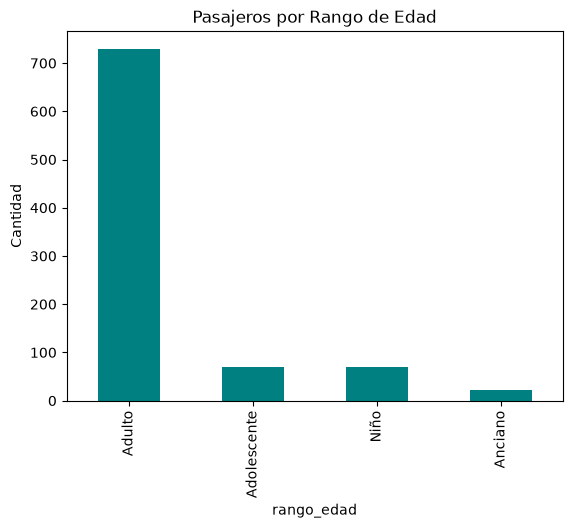

In [6]:
# Gráfico de Barras: Distribución de pasajeros por rango de edad

conteo_edades = df['rango_edad'].value_counts()
conteo_edades.plot(kind='bar', color='teal', title='Pasajeros por Rango de Edad', ylabel='Cantidad')

<Axes: title={'center': 'Edad vs Tarifa'}, xlabel='age', ylabel='fare'>

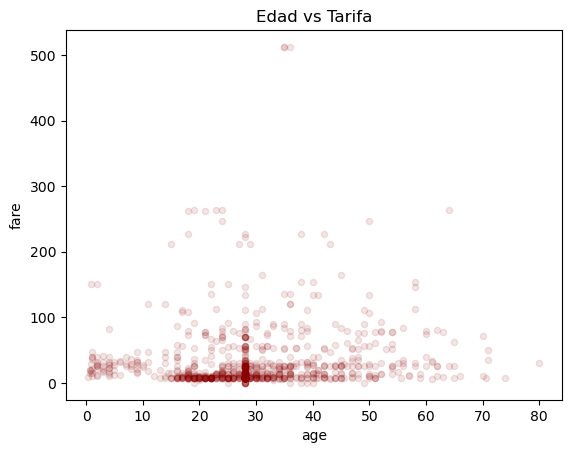

In [ ]:
# Gráfico de Dispersión (Scatter): Relación entre Edad y Tarifa pagada

df.plot(kind='scatter', x='age', y='fare', alpha=0.1, color='darkred', title='Edad vs Tarifa')

---
## 🏆 Ejercicios Prácticos para el Estudiante

A continuación, pondrás a prueba lo aprendido en cada una de las secciones de este laboratorio. Completa el código en las celdas correspondientes

**Ejercicio 1: Estadística Descriptiva**
* ¿Cuál fue la tarifa (`fare`) más barata pagada en el Titanic?
* ¿Cuál fue la tarifa más cara?
* *Pista: Usa los métodos `.min()` y `.max()` en la columna correspondiente.*

**Ejercicio 2: Agrupamiento (Groupby)**
* Calcula la **edad promedio** de los pasajeros agrupada por el puerto de embarque (`embark_town`).
* *Pista: Usa `groupby` seleccionando el puerto, luego la columna de edad, y finalmente aplica `.mean()`.*

**Ejercicio 3: Operaciones entre/con columnas (Nuevas variables)**
* Imagina que hubo un error y todas las tarifas registradas (`fare`) deben incluir un 10% extra de impuestos.
* Crea una nueva columna llamada `tarifa_con_impuesto` que multiplique la columna `fare` original por dicho impuesto.
* Muestra las primeras 5 filas de las columnas `fare` y `tarifa_con_impuesto`.

**Ejercicio 4: Ordenamiento**
* ¿Quiénes fueron los **3 pasajeros de mayor edad** a bordo?
* Encuéntralos usando `.nlargest()` o `.sort_values()` y muestra solo las columnas `who`, `age` y `class`.

**Ejercicio 5: Visualización Rápida**
* Genera un **gráfico de barras horizontal** (`kind='barh'`) que muestre la cantidad total de pasajeros que embarcaron en cada puerto (`embark_town`).
* *Pista: Primero debes contar los valores con `.value_counts()` y luego usar `.plot()`.*


In [ ]:
tarifa_maxima = (df['fare'].max())
tarifa_mínima = (df['fare'].min())

""" Utilizo df["fare"] para indiacar el apartado de tarifas y la funcion min y max para hallar el valor mínima y máximo respectivamente
"""
print(f"La tarifa mínima es {tarifa_mínima}, y la tarifa máxima {tarifa_maxima}")


La tarifa mínima es 0.0, y la tarifa máxima 512.3292


In [ ]:
df.groupby('embark_town', observed=True)['age'].mean()
""" decido utilizar groupby porque me permite utilizar como primer parametro la columna que deseo seleccionar como nombre de un "onjunto" 
y y el siguiente parametro los elementos de ese conjunto y luego la funcion .mean() para obtener el promedio
"""


'         '

In [ ]:
df["tarifa_con_impuesto"] = df["fare"] + (df["fare"]*0.10)

""" Decido crear la columna tarifa_con_impuestos sumando los valores de la columna "fare" y los valores de "fare" * 0.10 y esto los convierto en una 
columna que me de valores de fare * 1.1, en el siguiente paso dicido juntarla con la tabla fare y la funcion .head(5) para mostrar los primeros
5 valores 

 """

df[["fare", "tarifa_con_impuesto"]].head(5)


,fare,tarifa_con_impuesto
0,7.2500,7.97500
1,71.2833,78.41163
2,7.9250,8.71750
3,53.1000,58.41000
4,8.0500,8.85500


In [ ]:
df_3_mayores = df.nlargest(3,"age")
df_3_mayores[['who', 'age', 'class']]

"""    
Con nlargest puedo utilizar 2 parametros, el primero siendo el numero de elementos mayores que deseo y el segundo de que conjunto deseo extraer los 
elementos, y la siguiente linea que deseo obtener solo las especificaciones de "who", "age", "class"
"""

#otra forma

"""
Otra forma curiosa sería a traves de ordenar los valores con la funcion sort_values, primer parametro el conjunto que deseo extraer los valores
y ascending = false para mostrar los valores de forma decreciente. Luego en la siguiente linea solo mostrar las especificaciones "who", "age", "class"
y poner la funcion .head(3) para mostrar los 3 primeros valores    
"""

df_ordenado = df.sort_values(by="age",ascending=False)
df_ordenado[["who","age","class"]].head(3)


,who,age,class
630,man,80.0,First
851,man,74.0,Third
493,man,71.0,First


' conteo_de_personas = cuenta la columna embark_town, su respectivo nombre del conjunto y su cantidad de elementos\nla siguiente linea de codigo .plot lo hago para crear una grafica kind = barh para decir que quiero una grafica horizontal, color = teal, '

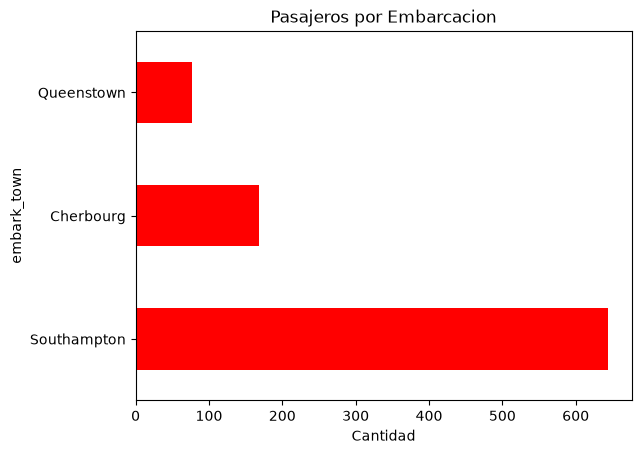

In [ ]:
conteo_de_personas = df['embark_town'].value_counts()
conteo_de_personas.plot(kind='barh', color='red', title='Pasajeros por puerto', xlabel='Cantidad')

""" conteo_de_personas = df['embark_town'].value_counts(), cuenta la columna embark_town, su respectivo nombre del conjunto y su cantidad de elementos
la siguiente linea de codigo .plot lo hago para crear una grafica kind = barh para decir que quiero una grafica horizontal
para ser color rojo, tittle = Pasajeros por puerto siendo este el titulo y que deseo que se ponga en el eje x que en este caso sería la cantidad"""

In [22]:
# Tu código para el Ejercicio aquí
